<a href="https://colab.research.google.com/github/pravee827/DataScience-and-Data-Analysis-with-python/blob/main/TASK3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 Rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN

/tmp/ipykernel_4843/3892916844.py:34: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)
/tmp/ipykernel_4843/3892916844.py:37: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

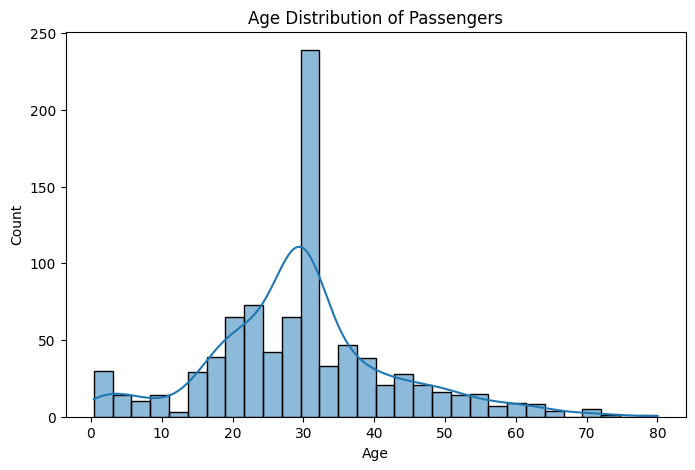

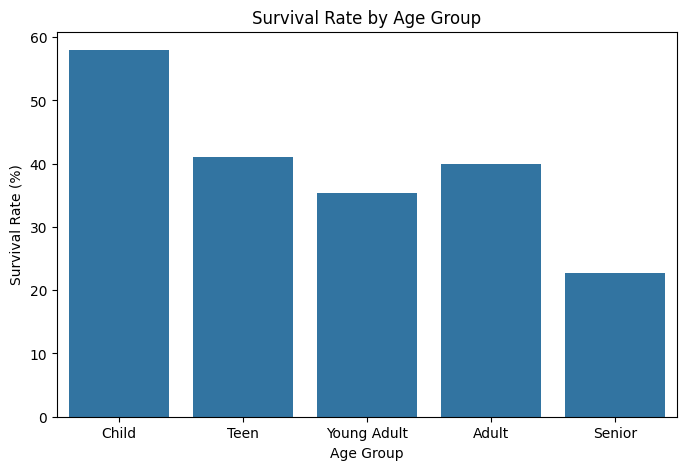

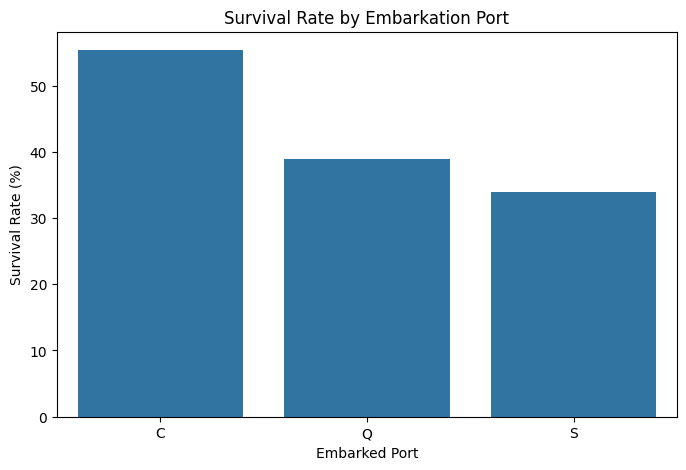

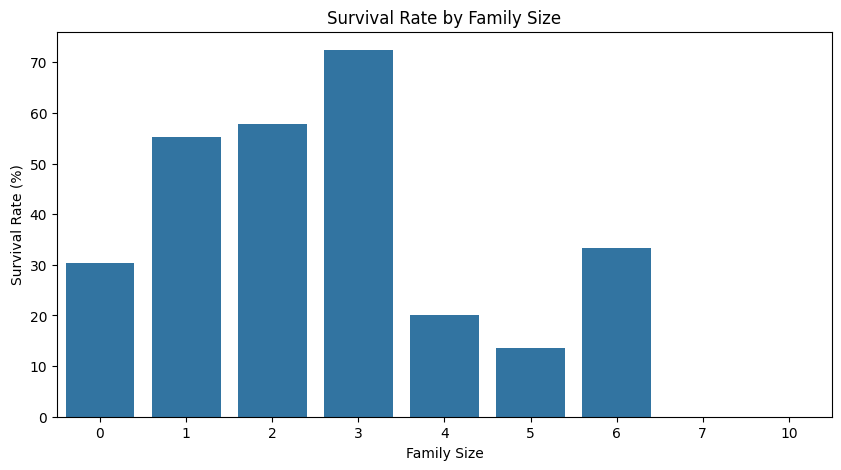

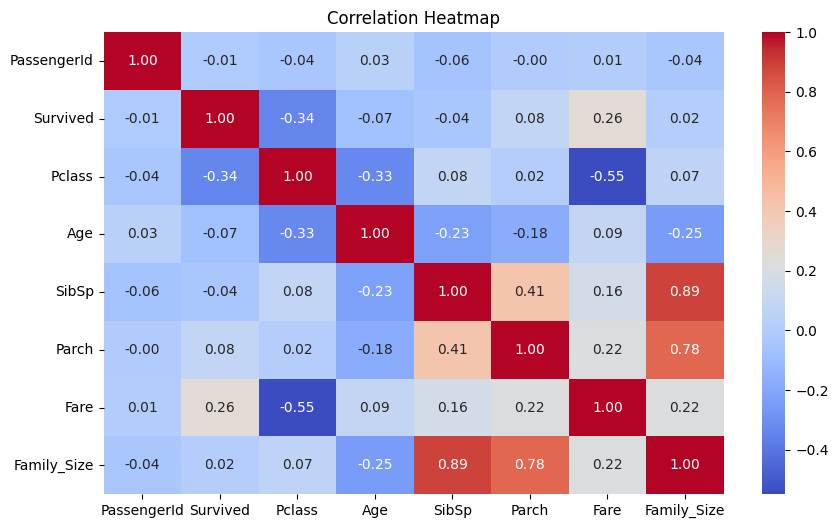


========== KEY INSIGHTS ==========
1. Age groups show different survival rates.
2. Embarkation ports had varying survival chances.
3. Family size influenced passenger survival.
4. Correlation heatmap helps identify relationships among variables.
5. Younger passengers often had better survival rates.


In [ ]:

# Data Science Internship Task 3
# ==========================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------
# Load Dataset
# ------------------------------------------
# Replace with your file path if needed
df = pd.read_csv("Titanic-Dataset.csv")

# Display first 5 rows
print("First 5 Rows:")
print(df.head())

# ------------------------------------------
# Basic Information
# ------------------------------------------
print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

# ------------------------------------------
# Data Cleaning
# ------------------------------------------

# Fill missing Age values with mean
df['Age'].fillna(df['Age'].mean(), inplace=True)

# Fill missing Embarked values with mode
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Drop Cabin column (many missing values)
if 'Cabin' in df.columns:
    df.drop('Cabin', axis=1, inplace=True)

# Verify missing values
print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

# ------------------------------------------
# Create Age Groups
# ------------------------------------------

bins = [0, 12, 19, 35, 60, 100]
labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']

df['Age_Group'] = pd.cut(df['Age'],
                         bins=bins,
                         labels=labels)

# ------------------------------------------
# Survival Rate by Age Group
# ------------------------------------------

age_survival = df.groupby('Age_Group')['Survived'].mean() * 100

print("\nSurvival Rate by Age Group (%):")
print(age_survival)

# ------------------------------------------
# Survival Rate by Embarkation Port
# ------------------------------------------

embark_survival = df.groupby('Embarked')['Survived'].mean() * 100

print("\nSurvival Rate by Embarkation Port (%):")
print(embark_survival)

# ------------------------------------------
# Family Size Analysis
# ------------------------------------------

df['Family_Size'] = df['SibSp'] + df['Parch']

family_survival = df.groupby('Family_Size')['Survived'].mean() * 100

print("\nSurvival Rate by Family Size (%):")
print(family_survival)

# ------------------------------------------
# Visualization 1: Age Distribution Histogram
# ------------------------------------------

plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

# ------------------------------------------
# Visualization 2: Survival Rate by Age Group
# ------------------------------------------

plt.figure(figsize=(8,5))
sns.barplot(
    x=age_survival.index,
    y=age_survival.values
)
plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate (%)")
plt.show()

# ------------------------------------------
# Visualization 3: Survival Rate by Embarked Port
# ------------------------------------------

plt.figure(figsize=(8,5))
sns.barplot(
    x=embark_survival.index,
    y=embark_survival.values
)
plt.title("Survival Rate by Embarkation Port")
plt.xlabel("Embarked Port")
plt.ylabel("Survival Rate (%)")
plt.show()

# ------------------------------------------
# Visualization 4: Survival by Family Size
# ------------------------------------------

plt.figure(figsize=(10,5))
sns.barplot(
    x=family_survival.index,
    y=family_survival.values
)
plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate (%)")
plt.show()

# ------------------------------------------
# Correlation Heatmap
# ------------------------------------------

numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,6))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title("Correlation Heatmap")
plt.show()

# ------------------------------------------
# Key Insights
# ------------------------------------------

print("\n========== KEY INSIGHTS ==========")

print("1. Age groups show different survival rates.")
print("2. Embarkation ports had varying survival chances.")
print("3. Family size influenced passenger survival.")
print("4. Correlation heatmap helps identify relationships among variables.")
print("5. Younger passengers often had better survival rates.")